In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_csv('../data/raw/ar_reviews_100k.tsv', sep="\t")

In [4]:
data['label'].unique()

array(['Positive', 'Mixed', 'Negative'], dtype=object)

In [6]:
data.head()

,label,text
0,Positive,ممتاز نوعا ما . النظافة والموقع والتجهيز والشا...
1,Positive,أحد أسباب نجاح الإمارات أن كل شخص في هذه الدول...
2,Positive,هادفة .. وقوية. تنقلك من صخب شوارع القاهرة الى...
3,Positive,خلصنا .. مبدئيا اللي مستني ابهار زي الفيل الاز...
4,Positive,ياسات جلوريا جزء لا يتجزأ من دبي . فندق متكامل...


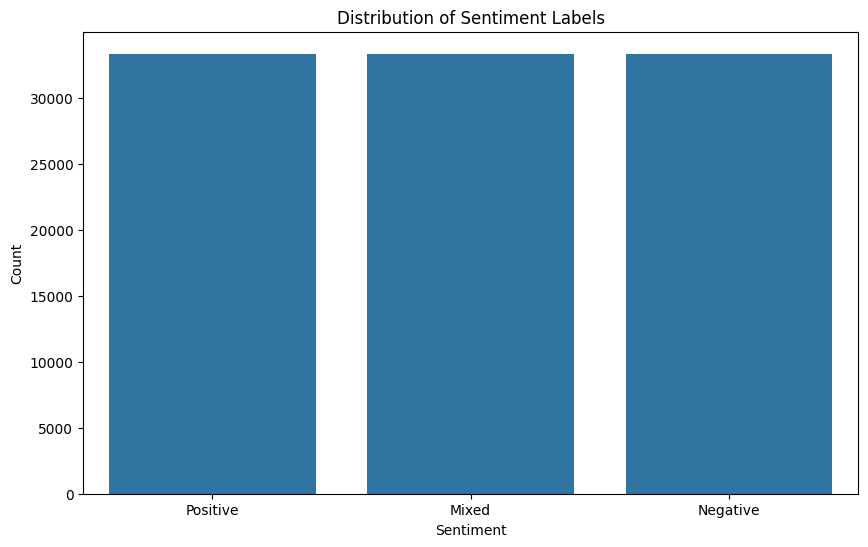

In [12]:
plt.figure(figsize=(10,6))
sns.countplot(x='label', data=data)
plt.title('Distribution of Sentiment Labels')
plt.xlabel('Sentiment')
plt.ylabel('Count') 
plt.show()

In [ ]:
data['text_length'] = data['text'].apply(len)

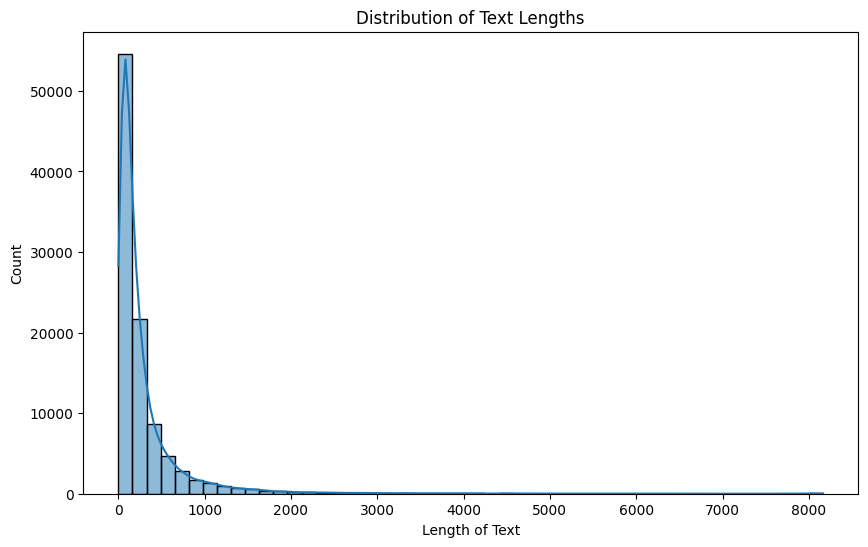

In [14]:
plt.figure(figsize=(10,6))
sns.histplot(data['text_length'], bins=50, kde=True)
plt.title('Distribution of Text Lengths')
plt.xlabel('Length of Text')
plt.ylabel('Count')
plt.show()

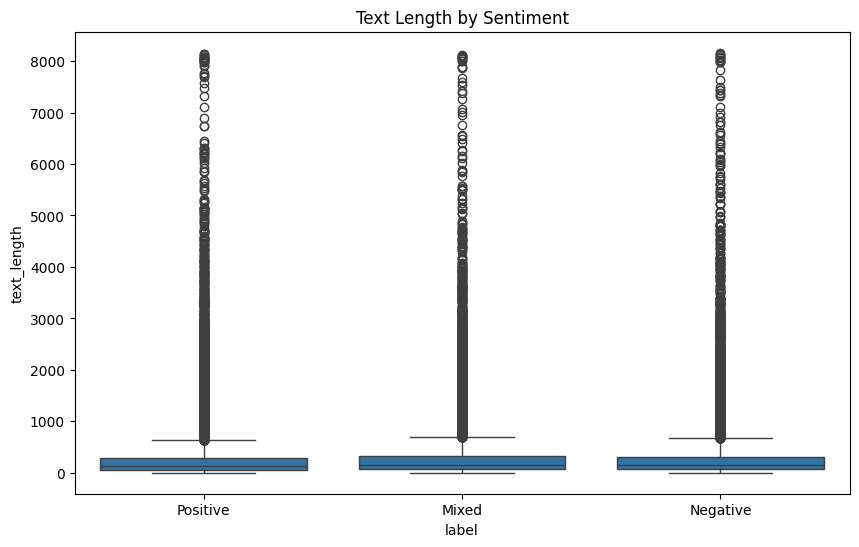

In [16]:
plt.figure(figsize=(10,6))
sns.boxplot(x='label', y='text_length', data=data)
plt.title('Text Length by Sentiment')
plt.show()

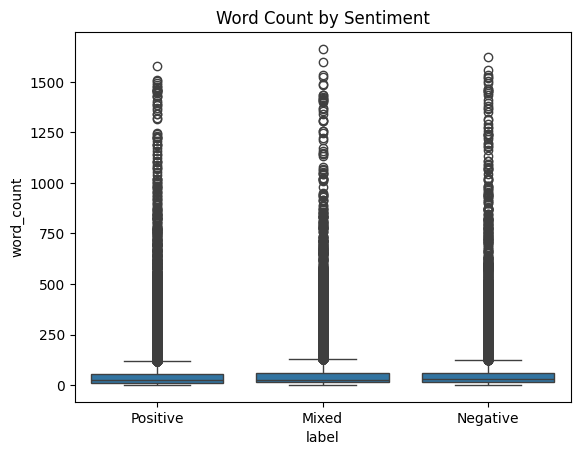

In [18]:
data['word_count'] = data['text'].apply(lambda x: len(str(x).split()))

sns.boxplot(x='label', y='word_count', data=data)
plt.title('Word Count by Sentiment')
plt.show()


In [7]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(2,2), stop_words='english')
X = vectorizer.fit_transform(data['text'])
sum_words = X.sum(axis=0)
words_freq = [(word, sum_words[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)
print(words_freq[:10])


[('هذا الكتاب', np.int64(4524)), ('لا يوجد', np.int64(3364)), ('هذه الرواية', np.int64(3109)), ('الكثير من', np.int64(2698)), ('في هذا', np.int64(2630)), ('أكثر من', np.int64(2558)), ('لم يكن', np.int64(2496)), ('مخيب للأمل', np.int64(2314)), ('كل شي', np.int64(2252)), ('في كل', np.int64(2250))]
